<a href="https://colab.research.google.com/github/komalavallisundaram/client-query-/blob/main/ML_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:

!pip install xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans




In [4]:

from google.colab import files
uploaded = files.upload()

df = pd.read_csv("/content/Fitbit_dataset.csv")
df.head()

Saving Fitbit_dataset.csv to Fitbit_dataset (2).csv


,Unnamed: 0,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned (kcal)
0,0,56,Female,53.8,1.62,163.0,149.0,71.0,1.01,HIIT,22.1,3.5,3,1,20.4,9.5,0.847826,8.054348,437.7
1,1,46,Male,54.9,1.75,170.0,126.0,73.0,0.25,Yoga,19.9,3.4,3,0,18.0,3.0,0.546392,1.639175,22.5
2,2,32,Female,68.5,1.61,190.0,171.0,60.0,0.33,HIIT,20.4,2.7,3,1,26.5,9.5,0.853846,8.111538,183.4
3,3,25,Male,98.8,1.86,189.0,135.0,69.0,0.78,Yoga,30.3,4.4,3,0,28.5,3.0,0.550000,1.650000,127.2
4,4,38,Male,95.5,1.71,176.0,138.0,66.0,0.55,Cardio,23.7,2.2,2,0,32.5,7.0,0.654545,4.581818,240.7


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14102 entries, 0 to 14101
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     14102 non-null  int64  
 1   Age                            14102 non-null  int64  
 2   Gender                         14102 non-null  int64  
 3   Weight (kg)                    14102 non-null  float64
 4   Height (m)                     14102 non-null  float64
 5   Max_BPM                        14102 non-null  float64
 6   Avg_BPM                        14102 non-null  float64
 7   Resting_BPM                    14102 non-null  float64
 8   Session_Duration (hours)       14102 non-null  float64
 9   Workout_Type                   14102 non-null  int64  
 10  Fat_Percentage                 14102 non-null  float64
 11  Water_Intake (liters)          14102 non-null  float64
 12  Workout_Frequency (days/week)  14102 non-null 

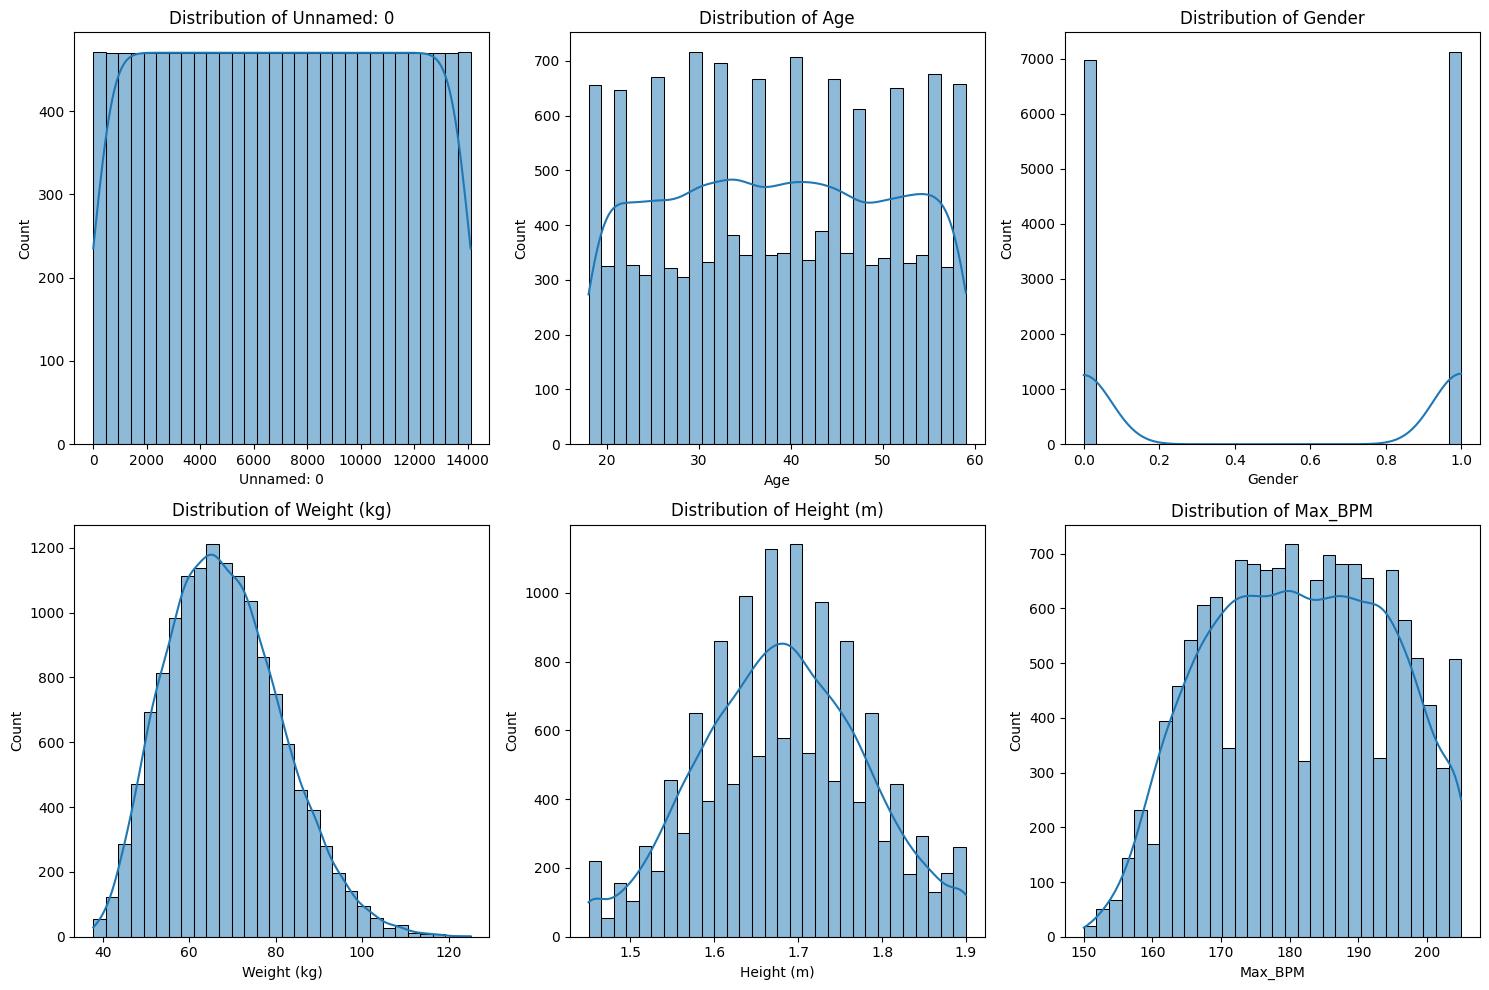

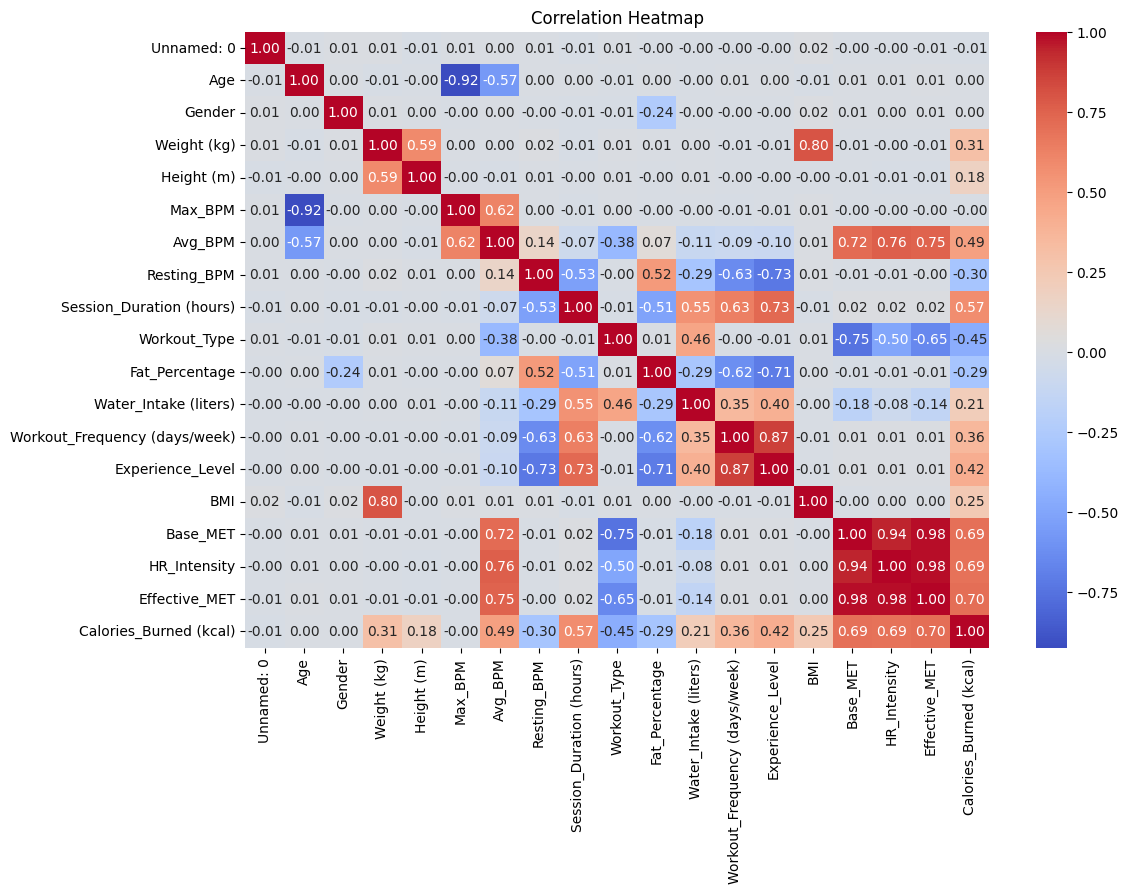

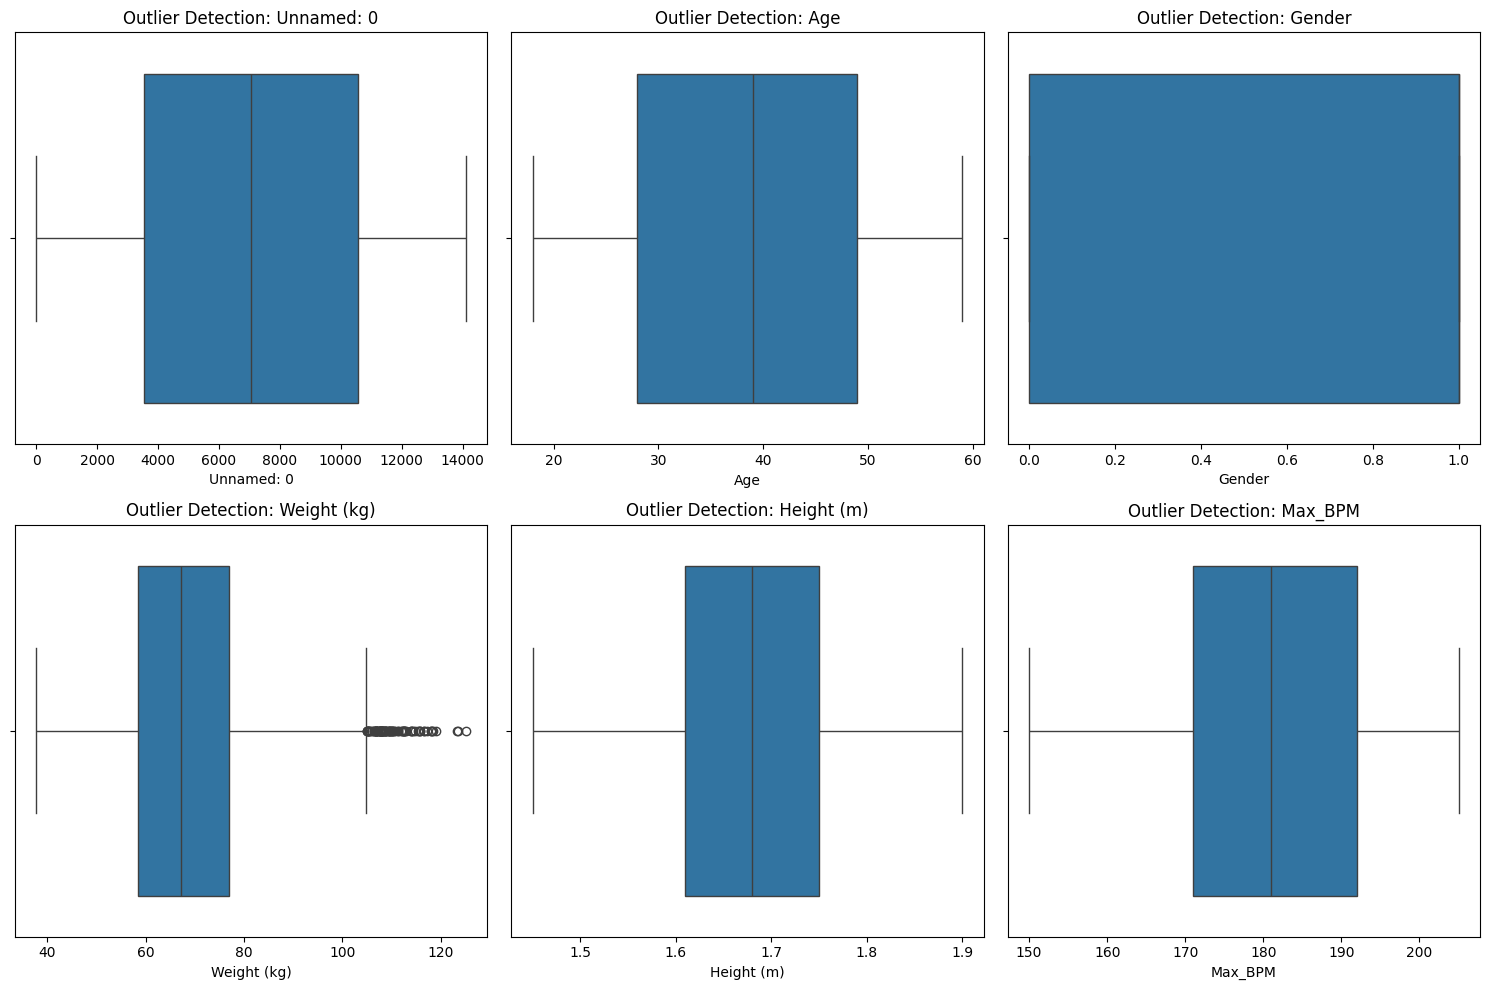

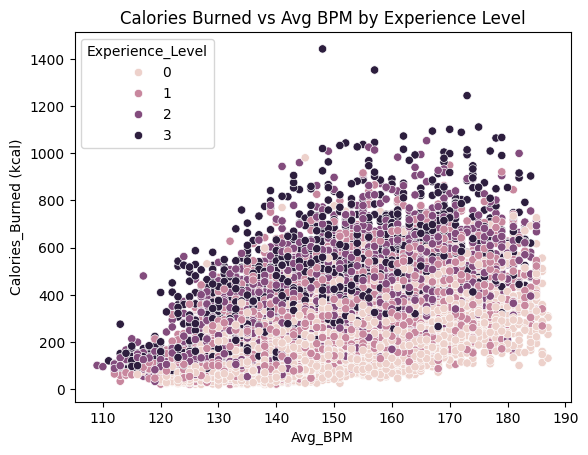

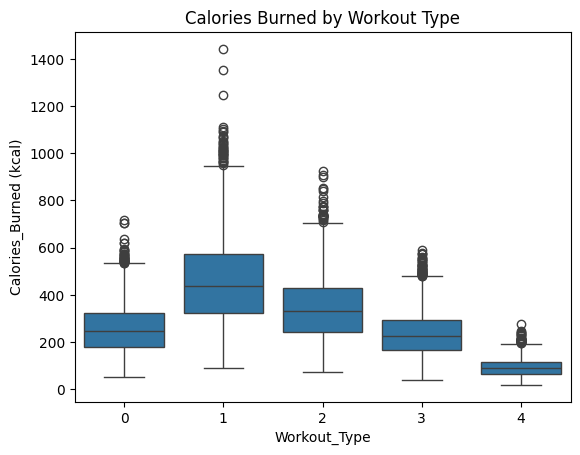

In [17]:
print(df.info())
print(df.describe())
print("Missing values per column:\n", df.isnull().sum())
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(15,10))
for i, col in enumerate(numeric_cols[:6]):
    plt.subplot(2,3,i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

plt.figure(figsize=(15,10))
for i, col in enumerate(numeric_cols[:6]):
    plt.subplot(2,3,i+1)
    sns.boxplot(x=df[col])
    plt.title(f"Outlier Detection: {col}")
plt.tight_layout()

sns.scatterplot(x=df['Avg_BPM'], y=df[target_col], hue=df['Experience_Level'])
plt.title("Calories Burned vs Avg BPM by Experience Level")
plt.show()

sns.boxplot(x=df['Workout_Type'], y=df[target_col])
plt.title("Calories Burned by Workout Type")
plt.show()


In [8]:
print(df.columns)


Index(['Unnamed: 0', 'Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM',
       'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Workout_Type',
       'Fat_Percentage', 'Water_Intake (liters)',
       'Workout_Frequency (days/week)', 'Experience_Level', 'BMI', 'Base_MET',
       'HR_Intensity', 'Effective_MET', 'Calories_Burned (kcal)'],
      dtype='object')


In [13]:

print("Columns in dataset:", df.columns.tolist())

target_col = [col for col in df.columns if "calories_burned" in col.lower()]
if not target_col:
    raise ValueError("Target column not found. Please check dataset columns.")
else:
    target_col = target_col[0]

print("Target column detected:", target_col)
X = df.drop(columns=[target_col])
y = df[target_col]

df.fillna(df.mean(numeric_only=True), inplace=True)
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns detected:", categorical_cols)

for col in categorical_cols:
    X[col] = LabelEncoder().fit_transform(X[col])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Columns in dataset: ['Unnamed: 0', 'Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI', 'Base_MET', 'HR_Intensity', 'Effective_MET', 'Calories_Burned (kcal)']
Target column detected: Calories_Burned (kcal)
Categorical columns detected: []


In [14]:

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "KNN": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "SVR": SVR(),
    "XGBoost": XGBRegressor()
}

results = []
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(results, columns=["Model","MAE","RMSE","R2"])
results_df.sort_values(by="R2", ascending=False)


,Model,MAE,RMSE,R2
7,XGBoost,5.314001,8.070494,0.997925
5,Random Forest,3.916219,8.467317,0.997716
4,Decision Tree,8.340518,13.890245,0.993855
3,KNN,31.841397,45.692716,0.933501
0,Linear Regression,34.626756,52.784061,0.911258
1,Ridge,34.628516,52.786023,0.911252
2,Lasso,34.894950,53.718784,0.908087
6,SVR,32.829369,64.767587,0.866390


Best Model: XGBoost


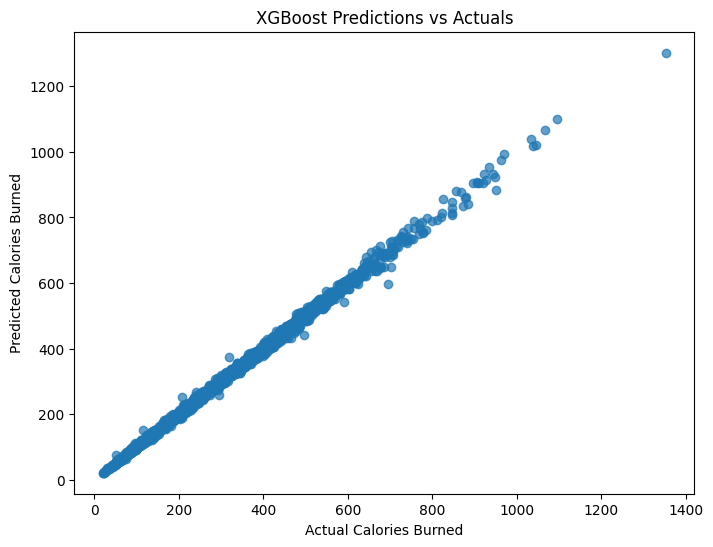

In [15]:

best_model_name = results_df.sort_values(by="R2", ascending=False).iloc[0,0]
print("Best Model:", best_model_name)

best_model = models[best_model_name]
y_pred = best_model.predict(X_test)

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Calories Burned")
plt.ylabel("Predicted Calories Burned")
plt.title(f"{best_model_name} Predictions vs Actuals")
plt.show()


Silhouette Score: 0.4216016317059872


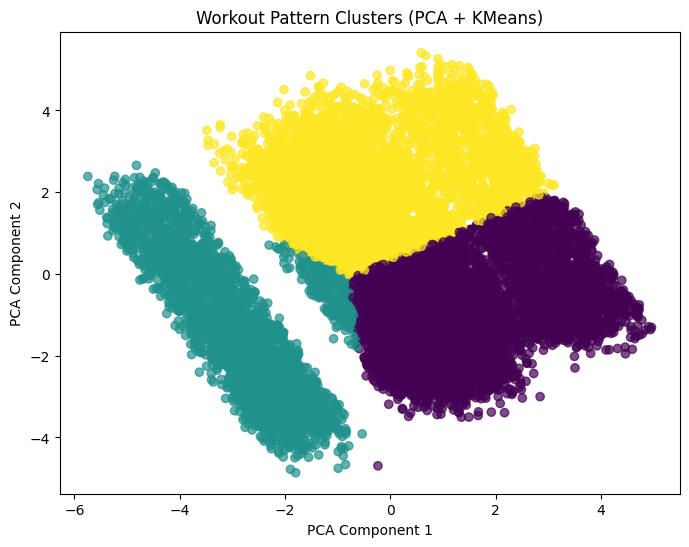

Cluster Feature Means:
          Unnamed: 0       Age    Gender  Weight (kg)  Height (m)   Max_BPM  \
Cluster                                                                      
0          0.004342 -0.042678 -0.025828     0.008717    0.000609  0.051014   
1         -0.003421  0.099543 -0.019657     0.020827    0.018434 -0.115979   
2         -0.004090 -0.004343  0.051358    -0.026923   -0.013353  0.003159   

          Avg_BPM  Resting_BPM  Session_Duration (hours)  Workout_Type  \
Cluster                                                                  
0        0.386811     0.554637                 -0.572565     -0.402482   
1       -1.133846     0.006251                 -0.016531      1.364169   
2        0.195875    -0.821870                  0.855246     -0.328396   

         Fat_Percentage  Water_Intake (liters)  Workout_Frequency (days/week)  \
Cluster                                                                         
0              0.537927              -0.500920      

In [16]:

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
X_cluster = df.drop(columns=[target_col])

categorical_cols = X_cluster.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    X_cluster[col] = LabelEncoder().fit_transform(X_cluster[col])

scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)

sil_score = silhouette_score(X_pca, clusters)
print("Silhouette Score:", sil_score)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis', alpha=0.7)
plt.title("Workout Pattern Clusters (PCA + KMeans)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

cluster_df = pd.DataFrame(X_cluster_scaled, columns=X_cluster.columns)
cluster_df['Cluster'] = clusters
cluster_summary = cluster_df.groupby('Cluster').mean()
print("Cluster Feature Means:\n", cluster_summary)
